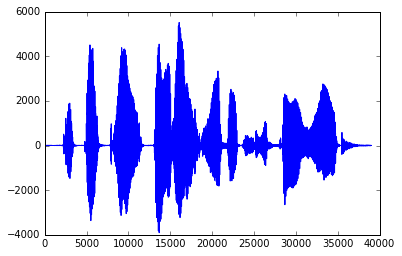

In [1]:
%matplotlib inline
import numpy as np
import scipy.io.wavfile as wf
import scipy.fftpack as fp
import matplotlib.pyplot as plt
import math as math

rate, data = wf.read('sx319.wav')
plt.plot(data)

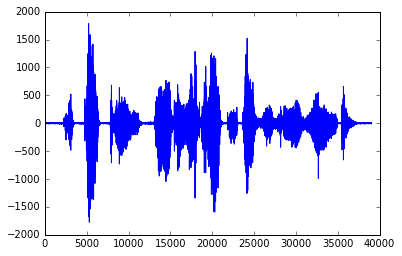

In [3]:
#Pre-Emphasis
a = 0.97
data = data[1:] - a*data[:-1]
plt.plot(data)

In [4]:
WINDOW_SIZE = 25 #msec
SAMPLE_PERIOD = 1.0 / rate *1000 #msec/samples
FRAME_SIZE = int(WINDOW_SIZE / SAMPLE_PERIOD)
FRAME_SHIFT = rate / 100
MEL_FILTERS = 20
#FRAMES_COUNT = int(math.floor(len(data)/float(FRAME_SHIFT)))-1
#FILTER_SIZE = 2**int(math.ceil(math.log(FRAMES_COUNT,2)))

print "Sample Rate   =", rate
print "Window Size   =", WINDOW_SIZE
print "Sample Period =", SAMPLE_PERIOD
print "Frame Size    =", FRAME_SIZE
print "Frame Shift   =", FRAME_SHIFT
print "Points Count  =", len(data)
#print "Frames Count  =", FRAMES_COUNT
print "MEL Filters   =", MEL_FILTERS
#print "Filter Size   =", FILTER_SIZE

Sample Rate   = 16000
Window Size   = 25
Sample Period = 0.0625
Frame Size    = 400
Frame Shift   = 160
Points Count  = 39013
MEL Filters   = 20


In [5]:
def createFrames(data,fillZeros):
    start = 0
    end = start + FRAME_SIZE
    frames=[]
    #for n in range(len(data)):
    while start < len(data):
        frame=data[start:end]
        if frame.shape[0] < FRAME_SIZE:            
            if fillZeros==1:
                for i in range(FRAME_SIZE - frame.shape[0]):
                    frame = np.append(frame , 0)
                frames.append(frame)
        else:
            frames.append(frame)
            
        start = start + FRAME_SHIFT
        end = end + FRAME_SHIFT

    digitalWave = np.array(frames)
    return digitalWave

In [6]:
#Create array with Frames
frames = createFrames(data,0)
FRAMES_COUNT = len(frames)
FILTER_SIZE = 2**int(math.ceil(math.log(FRAME_SIZE,2)))

print "Frames Count  =", FRAMES_COUNT
print "Filter Size   =", FILTER_SIZE
print "Shape frames  =" ,frames.shape

#Hamming Window
framesH = frames * np.hamming(FRAME_SIZE)
print "Shape framesH     =" ,framesH.shape

#Fast Furier Transform
framesH_FFT = np.fft.fft(framesH,FILTER_SIZE  )
print "Shape framesH_FFT =" ,framesH_FFT.shape

#Frames results
fResult=abs(framesH_FFT[:,:FILTER_SIZE/2])**2


print "Shape fResult     =" ,fResult.shape

Frames Count  = 242
Filter Size   = 512
Shape frames  = (242, 400)
Shape framesH     = (242, 400)
Shape framesH_FFT = (242, 512)
Shape fResult     = (242, 256)


(<matplotlib.axes._subplots.AxesSubplot at 0x7f640bfe1750>,
 <matplotlib.text.Text at 0x7f640c018710>)

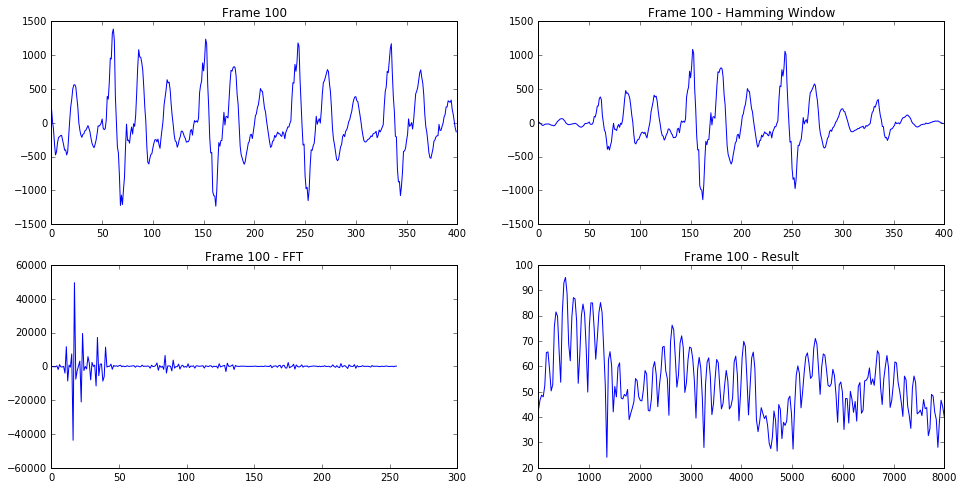

In [6]:
nfft = FILTER_SIZE
freq = np.linspace(0,rate/2.,nfft/2)
fig,ax = plt.subplots(figsize =(16,8))
plt.subplot(2,2,1),plt.plot(frames[100]),plt.title("Frame 100")
plt.subplot(2,2,2),plt.plot(framesH[100]),plt.title("Frame 100 - Hamming Window")
plt.subplot(2,2,3),plt.plot(framesH_FFT[100][:256].real),plt.title("Frame 100 - FFT")
plt.subplot(2,2,4),plt.plot(freq,10*np.log10(fResult[100])),plt.title("Frame 100 - Result")

Lenght melList      = 22
Lenght hertzMelList = 22

Mel      = [401.9705861630035, 518.0683223794471, 634.1660585958906, 750.2637948123341, 866.3615310287777, 982.4592672452212, 1098.5570034616649, 1214.6547396781084, 1330.752475894552, 1446.8502121109955, 1562.947948327439, 1679.0456845438825, 1795.143420760326, 1911.2411569767696, 2027.3388931932132, 2143.4366294096567, 2259.5343656261, 2375.6321018425438, 2491.7298380589873, 2607.827574275431, 2723.9253104918744, 2840.0230467083184]

MelHertz = [300.0, 408.51, 528.79, 662.13, 809.93, 973.77, 1155.39, 1356.71, 1579.88, 1827.27, 2101.5, 2405.48, 2742.45, 3115.99, 3530.06, 3989.05, 4497.86, 5061.87, 5687.08, 6380.13, 7148.38, 8000.0]


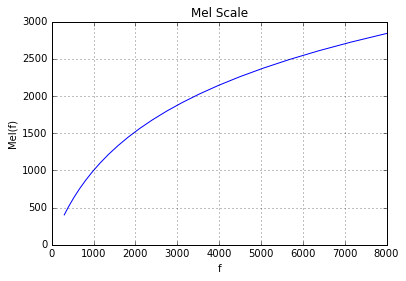

In [9]:
def Hertz2Mel(f):
    return 2595.0 * math.log(1.0 + (f/700.0) , 10)

def Mel2Hertz(m):
    return round(700*(10**(m/2595.0)-1),2)


def Mel(lower,upper,leng):
    lowerMel = Hertz2Mel(lower)
    upperMel = Hertz2Mel(upper)
    step = (upperMel-lowerMel)/(leng+1)
    
    m=[]
    m.append(lowerMel)
    for n in range(1,leng+1):
        m.append(m[n-1]+step)
    m.append(upperMel)
    return m


def MelHertz(m):
    h=[]
    for n in range(0,len(m)):
        h.append(Mel2Hertz(m[n]))
    return h
    

melList = Mel(300,8000,MEL_FILTERS)
hertzMelList = MelHertz(melList)

print "Lenght melList      =",len(melList)
print "Lenght hertzMelList =",len(hertzMelList)
print ""
print "Mel      =",melList
print ""
print "MelHertz =",hertzMelList

fig1 = plt.figure()
ax = fig1.add_subplot(111)
x_points = hertzMelList
y_points = melList
p = ax.plot(x_points, y_points, 'b')
ax.grid()
ax.set_xlabel('f')
ax.set_ylabel('Mel(f)')
ax.set_title('Mel Scale')

In [10]:
def FFTBin(m,nf):
    bin1=[]
    for n in range(0,len(m)):
        bin1.append(int(math.floor((nf+1)*m[n]/rate)))
    return bin1



fft_bin = FFTBin(hertzMelList,nfft)
print "List of bins   =",fft_bin
print "Number of bins =",len(fft_bin)

List of bins   = [9, 13, 16, 21, 25, 31, 37, 43, 50, 58, 67, 77, 87, 99, 113, 127, 144, 162, 182, 204, 229, 256]
Number of bins = 22


Shape Filterbak = (22, 256)


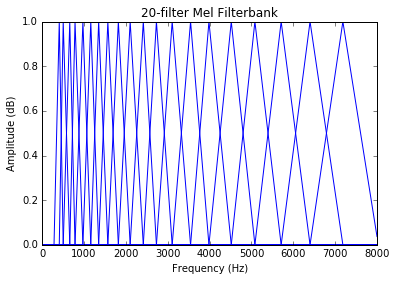

In [12]:
HFilter=[]
HF=[]

freq = np.linspace(0,rate/2,nfft/2)
for m in range(0,len(fft_bin)):
    for k in range(0,FILTER_SIZE/2):
        if k < fft_bin[m-1]:
            HFilter.append(0)
        elif k <= fft_bin[m]:
            HFilter.append((k-fft_bin[m-1])/float((fft_bin[m]-fft_bin[m-1])))
        elif k <= fft_bin[m+1]:
            HFilter.append((fft_bin[m+1] - k)/float((fft_bin[m+1]-fft_bin[m])))
        else:
            HFilter.append(0)
    HF.append(HFilter)
    HFilter=[]


HF = np.array(HF)
for r in range(0,21):
    plt.plot(freq,HF[r],'b') 
plt.title("20-filter Mel Filterbank")
plt.ylabel("Amplitude (dB)")    
plt.xlabel("Frequency (Hz)")  

print "Shape Filterbak =",HF.shape

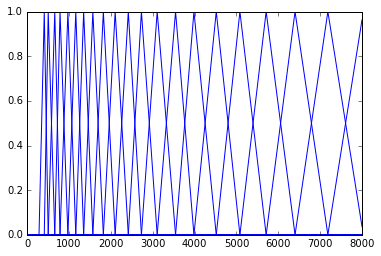

In [10]:
plt.plot(freq,HF.T,'b')

In [11]:
Mult = np.dot(fResult,HF.T)
print Mult.shape
print len(Mult)
eps = 1e-10
Mult[Mult<eps]=eps
print Mult[6]
Mult = np.log(Mult)

(242, 22)
242
[  1.00000000e-10   1.02530218e+02   1.56906833e+02   1.16793206e+02
   4.64298819e+02   5.57357457e+02   3.25469683e+02   8.48883003e+02
   1.40544905e+03   1.32018952e+03   2.13928591e+03   3.47057124e+03
   3.65733418e+03   5.77360447e+03   6.08236336e+03   1.26863073e+04
   1.66824525e+04   1.57148954e+04   2.21683758e+04   3.83464241e+04
   5.23358431e+04   2.31486508e+04]


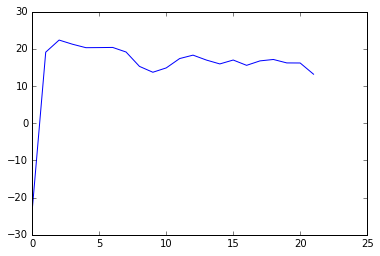

In [12]:
plt.plot(Mult[100])

In [13]:
import scipy.fftpack as dct
mfcc= dct.dct(Mult,n=12,axis=1)
print mfcc.shape

(242, 12)


In [14]:
print mfcc[100]

[ 361.9681223   -50.43491498  -97.51545067  -91.16129152  -64.9569583
  -83.95365955  -57.14861472  -48.27870777  -39.19814016  -28.27143857
  -17.12333526  -10.46904393]


(<matplotlib.axes._subplots.AxesSubplot at 0x7f5ce03027d0>,
 <matplotlib.image.AxesImage at 0x7f5ce026b950>)

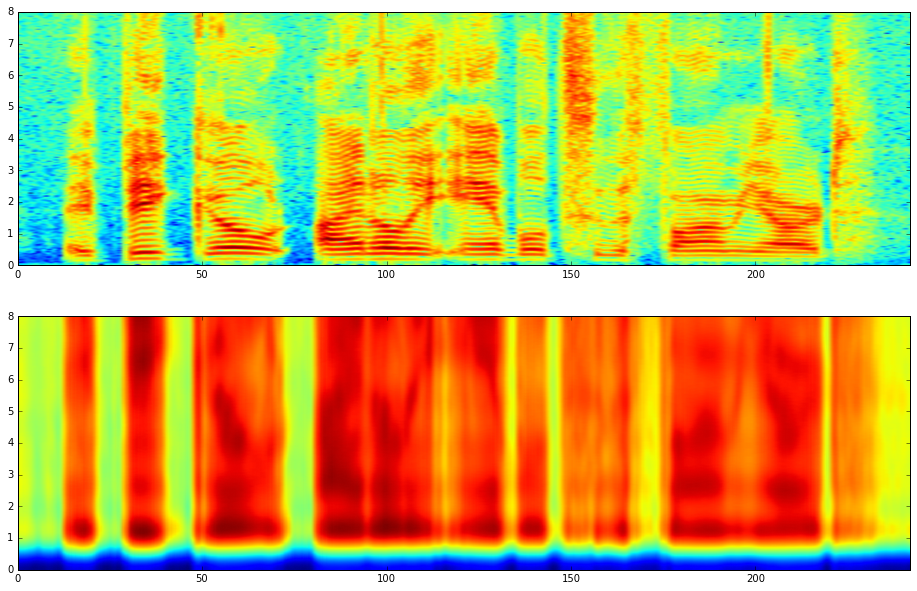

In [15]:
#test=np.real(dct.idct(finalDCT,2,nfft,norm='ortho',axis=1))
test=np.real(np.fft.ifft(mfcc,nfft,axis=1))[:,:nfft/2]
fig,ax = plt.subplots(figsize =(16,10))
plt.subplot(211),plt.imshow(np.log(fResult.T),origin="lower",aspect="auto",interpolation="bessel",extent=(0,242,0,rate/2000.))
plt.subplot(212),plt.imshow(test.T,origin="lower",aspect="auto",interpolation="bessel",extent=(0,242,0,rate/2000.))

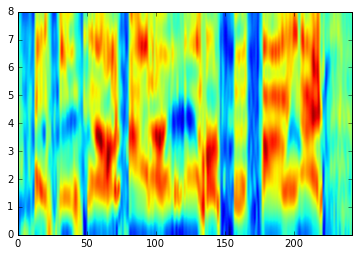

In [16]:
import scipy.io as sio
mat_contents = sio.loadmat('sx319-mfcc.mat')
test=np.real(np.fft.ifft(mat_contents['m'],nfft,axis=1))[:,:nfft/2]
plt.imshow(test.T,origin="lower",aspect="auto",interpolation="bessel",extent=(0,242,0,rate/2000.))